In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns
import os
from datetime import datetime, timedelta, timezone
# import  chi2_contingency
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler



In [61]:
data = pd.read_csv('advertisement.csv', dtype=str)

In [62]:
for column in data.columns:
    print(f"Column: {column}")

Column: Mã người đăng
Column: Mã bài đăng
Column: Mã dự án
Column: Tỉnh/Thành phố cũ
Column: Tỉnh/Thành phố mới
Column: Huyện/Quận cũ
Column: Phường/Xã cũ
Column: Phường mới
Column: Số nhà
Column: Đường
Column: Loại hình
Column: Cập nhât lần cuối
Column: Số tầng
Column: Có hướng ra đường
Column: Vĩ độ
Column: Kinh độ
Column: Tọa độ
Column: Tọa độ ID
Column: Giá (chữ)
Column: Chiều dài
Column: Chiều rộng
Column: Mức độ quảng cáo
Column: Đăng bởi Đối tác
Column: Ngày đăng
Column: Giá bán
Column: Hình thức
Column: Tình trạng nội thất
Column: Đặc điểm căn hộ
Column: Hướng cửa chính
Column: Loại hình căn hộ
Column: Hướng ban công
Column: Đơn giá (tr/m2)
Column: Giấy tờ pháp lý
Column: Số phòng ngủ
Column: Diện tích
Column: Số phòng vệ sinh
Column: Loại hình nhà ở
Column: Đặc điểm nhà/đất
Column: Hướng đất
Column: Loại hình đất
Column: Loại hình văn phòng


In [63]:
DROP_CLUMNS = ['Mã người đăng', 'Mã bài đăng', 'Mã dự án', 'Cập nhât lần cuối', 'Tọa độ', 'Tọa độ ID', 'Giá (chữ)', 'Hình thức', 'Tỉnh/Thành phố mới', 'Mức độ quảng cáo']
data = data.drop(columns=DROP_CLUMNS)

In [64]:
print(data.columns)

Index(['Tỉnh/Thành phố cũ', 'Huyện/Quận cũ', 'Phường/Xã cũ', 'Phường mới',
       'Số nhà', 'Đường', 'Loại hình', 'Số tầng', 'Có hướng ra đường', 'Vĩ độ',
       'Kinh độ', 'Chiều dài', 'Chiều rộng', 'Đăng bởi Đối tác', 'Ngày đăng',
       'Giá bán', 'Tình trạng nội thất', 'Đặc điểm căn hộ', 'Hướng cửa chính',
       'Loại hình căn hộ', 'Hướng ban công', 'Đơn giá (tr/m2)',
       'Giấy tờ pháp lý', 'Số phòng ngủ', 'Diện tích', 'Số phòng vệ sinh',
       'Loại hình nhà ở', 'Đặc điểm nhà/đất', 'Hướng đất', 'Loại hình đất',
       'Loại hình văn phòng'],
      dtype='object')


In [65]:

if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

if data['Giá bán'].dtype == 'object':
    data['Giá bán'] = pd.to_numeric(
    data['Giá bán'].str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
).astype('Int64')
    data['Giá Bán'] = data['Giá bán']


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


In [66]:
for column in data.columns:
    print(f"Column: {column}, dtype: {data[column].dtype}")
    print(f"Unique values: {data[column].unique()}")
    print(f"Number of unique values: {data[column].nunique()}")
    

Column: Tỉnh/Thành phố cũ, dtype: object
Unique values: ['Tp Hồ Chí Minh' 'Bình Dương' 'Bà Rịa - Vũng Tàu']
Number of unique values: 3
Column: Huyện/Quận cũ, dtype: object
Unique values: ['Quận 7' 'Thành phố Thủ Đức' 'Quận 8' 'Huyện Nhà Bè' 'Thành phố Dĩ An'
 'Quận 4' 'Quận 12' 'Huyện Bình Chánh' 'Quận 1' 'Thành phố Thuận An'
 'Quận 10' 'Quận Bình Thạnh' 'Quận Phú Nhuận' 'Quận Bình Tân'
 'Quận Tân Phú' 'Thành phố Thủ Dầu Một' 'Quận Gò Vấp' 'Quận Tân Bình'
 'Quận 3' 'Thành phố Vũng Tàu' 'Thị xã Bến Cát' 'Huyện Hóc Môn' 'Quận 6'
 'Thị xã Phú Mỹ' 'Quận 5' 'Quận 11' 'Thị xã Tân Uyên' 'Huyện Xuyên Mộc'
 'Thành phố Bà Rịa' 'Huyện Long Điền' 'Huyện Cần Giờ' 'Huyện Dầu Tiếng'
 'Huyện Củ Chi' 'Huyện Bàu Bàng' 'Huyện Châu Đức' 'Huyện Phú Giáo'
 'Huyện Đất Đỏ' 'Huyện Bắc Tân Uyên' 'Huyện Côn Đảo']
Number of unique values: 39
Column: Phường/Xã cũ, dtype: object
Unique values: ['Phường Tân Hưng' 'Phường Trường Thọ (Quận Thủ Đức cũ)' 'Phường 16'
 'Xã Phú Xuân' 'Phường Bình Thắng' 'Phường 18' 'Phường

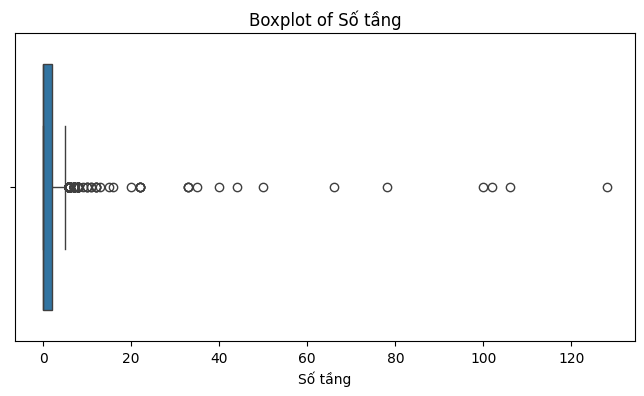

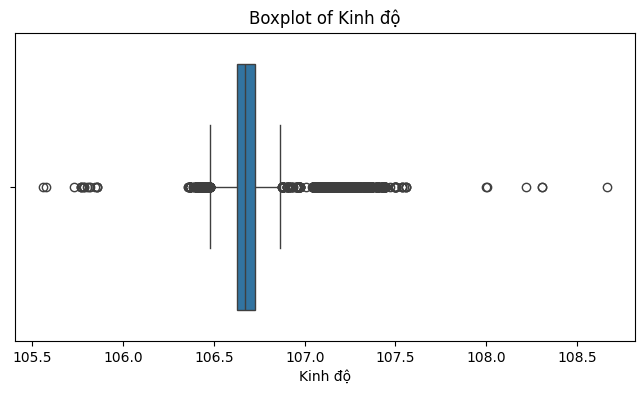

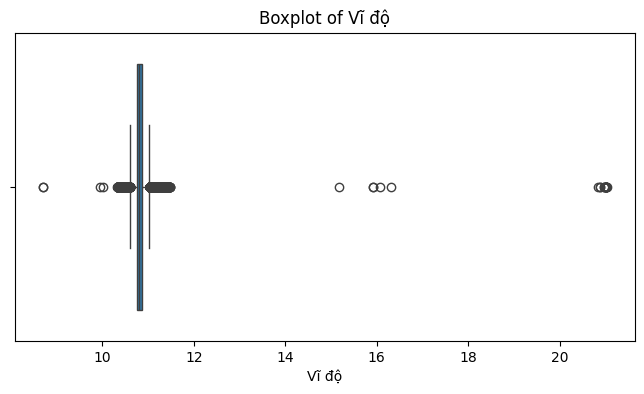

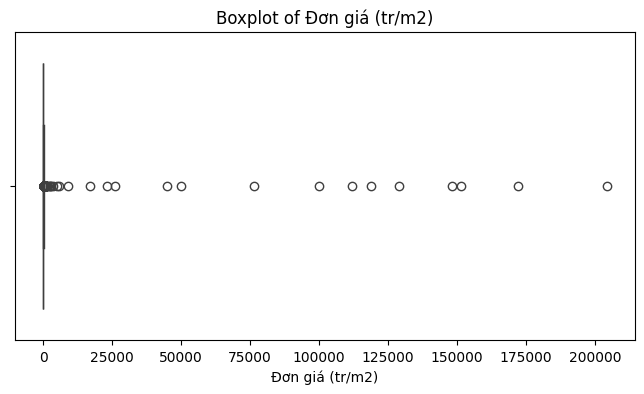

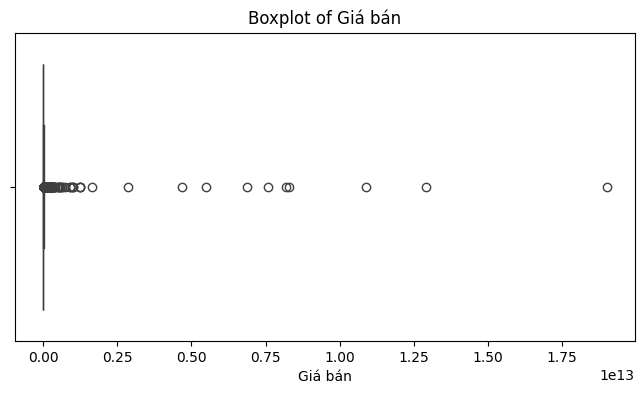

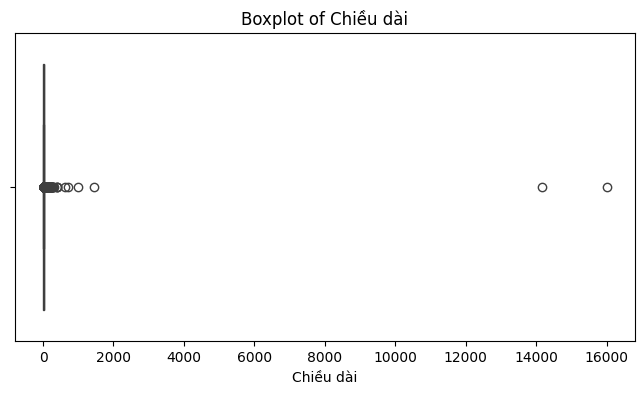

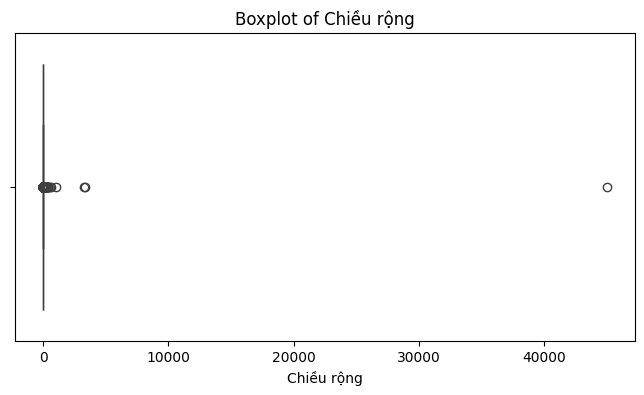

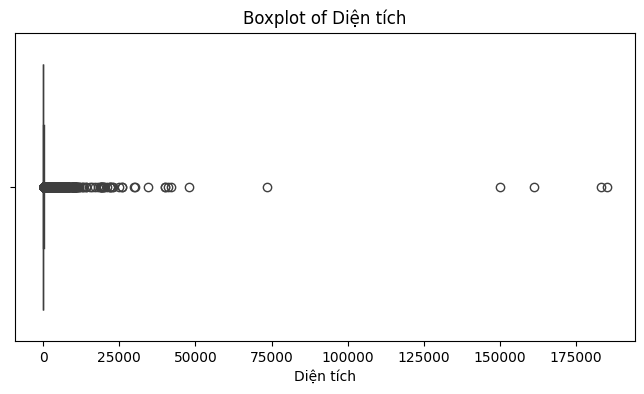

In [67]:
# Kiểm tra outliers bằng boxplot
numeric_columns = ['Số tầng', 'Kinh độ', 'Vĩ độ', 'Đơn giá (tr/m2)', 'Giá bán', 'Chiều dài', 'Chiều rộng', 'Diện tích']
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()
    


In [68]:
# Count outliers
for column in numeric_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Number of outliers in {column}: {len(outliers)}")

Number of outliers in Số tầng: 267
Number of outliers in Kinh độ: 1485
Number of outliers in Vĩ độ: 2613
Number of outliers in Đơn giá (tr/m2): 1173
Number of outliers in Giá bán: 3149
Number of outliers in Chiều dài: 2090
Number of outliers in Chiều rộng: 3806
Number of outliers in Diện tích: 4454


Text(0.5, 1.0, 'Correlation Heatmap')

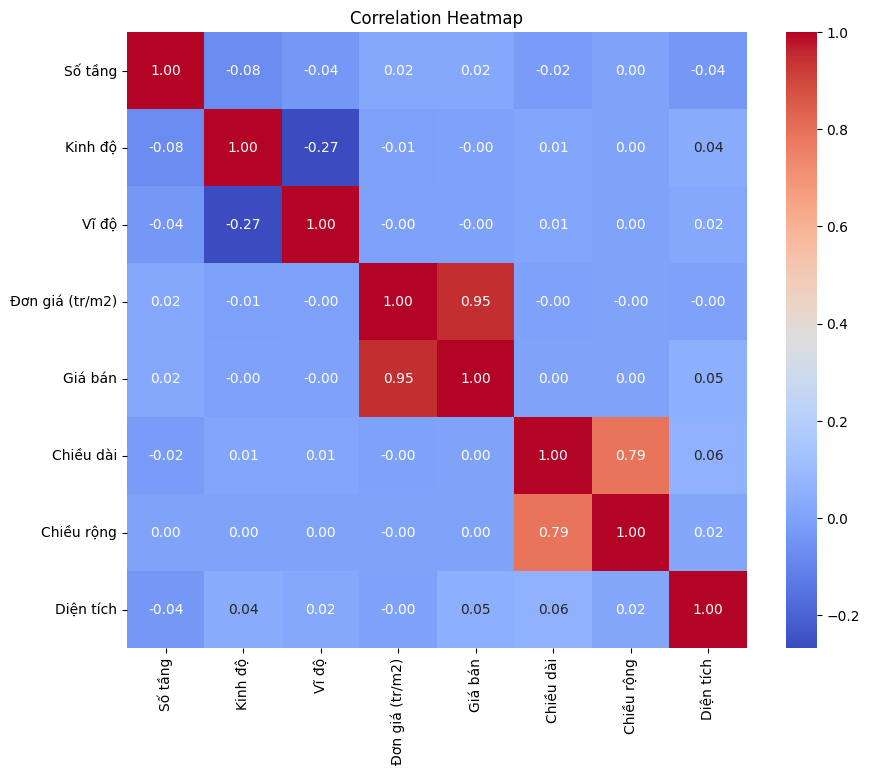

In [69]:
# Vẽ heatmap để kiểm tra tương quan giữa các biến số so với biến mục tiêu 'Giá bán'
plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_columns].corr()  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

,Giá bán nhóm,Đường,Số phòng vệ sinh,Số phòng ngủ,Số nhà,Phường/Xã cũ,Phường mới,Huyện/Quận cũ,Loại hình nhà ở,Giấy tờ pháp lý,...,Loại hình văn phòng,Đặc điểm nhà/đất,Loại hình căn hộ,Tình trạng nội thất,Loại hình đất,Đăng bởi Đối tác,Hướng đất,Hướng ban công,Ngày đăng,Hướng cửa chính
Giá bán nhóm,1.000,0.373,0.360,0.348,0.328,0.319,0.309,0.273,0.246,0.237,...,0.200,0.165,0.142,0.137,0.079,0.057,0.044,0.037,0.031,0.012
Đường,0.373,1.000,0.291,0.257,0.388,0.672,0.684,0.763,0.396,0.324,...,0.375,0.309,0.510,0.266,0.391,0.287,0.216,0.282,0.076,0.221
Số phòng vệ sinh,0.360,0.291,1.000,0.571,0.331,0.175,0.165,0.128,0.149,0.201,...,NaN,0.096,0.331,0.174,NaN,0.045,NaN,0.000,0.000,0.018
Số phòng ngủ,0.348,0.257,0.571,1.000,0.255,0.118,0.113,0.083,0.151,0.158,...,NaN,0.078,0.335,0.156,NaN,0.041,NaN,0.000,0.000,0.018
Số nhà,0.328,0.388,0.331,0.255,1.000,0.383,0.392,0.398,0.071,0.158,...,0.000,0.000,0.578,0.305,0.326,0.000,0.098,0.279,0.000,0.151
Phường/Xã cũ,0.319,0.672,0.175,0.118,0.383,1.000,0.871,0.845,0.268,0.217,...,0.305,0.132,0.254,0.163,0.358,0.340,0.205,0.212,0.000,0.166
Phường mới,0.309,0.684,0.165,0.113,0.392,0.871,1.000,0.986,0.255,0.198,...,0.315,0.116,0.219,0.176,0.310,0.327,0.182,0.180,0.035,0.159
Huyện/Quận cũ,0.273,0.763,0.128,0.083,0.398,0.845,0.986,1.000,0.195,0.137,...,0.211,0.154,0.151,0.126,0.222,0.280,0.140,0.133,0.000,0.137
Loại hình nhà ở,0.246,0.396,0.149,0.151,0.071,0.268,0.255,0.195,1.000,0.064,...,NaN,0.061,NaN,0.073,NaN,0.050,NaN,NaN,0.071,0.008
Giấy tờ pháp lý,0.237,0.324,0.201,0.158,0.158,0.217,0.198,0.137,0.064,1.000,...,0.357,0.161,0.056,0.102,0.153,0.057,0.045,0.055,0.094,0.047


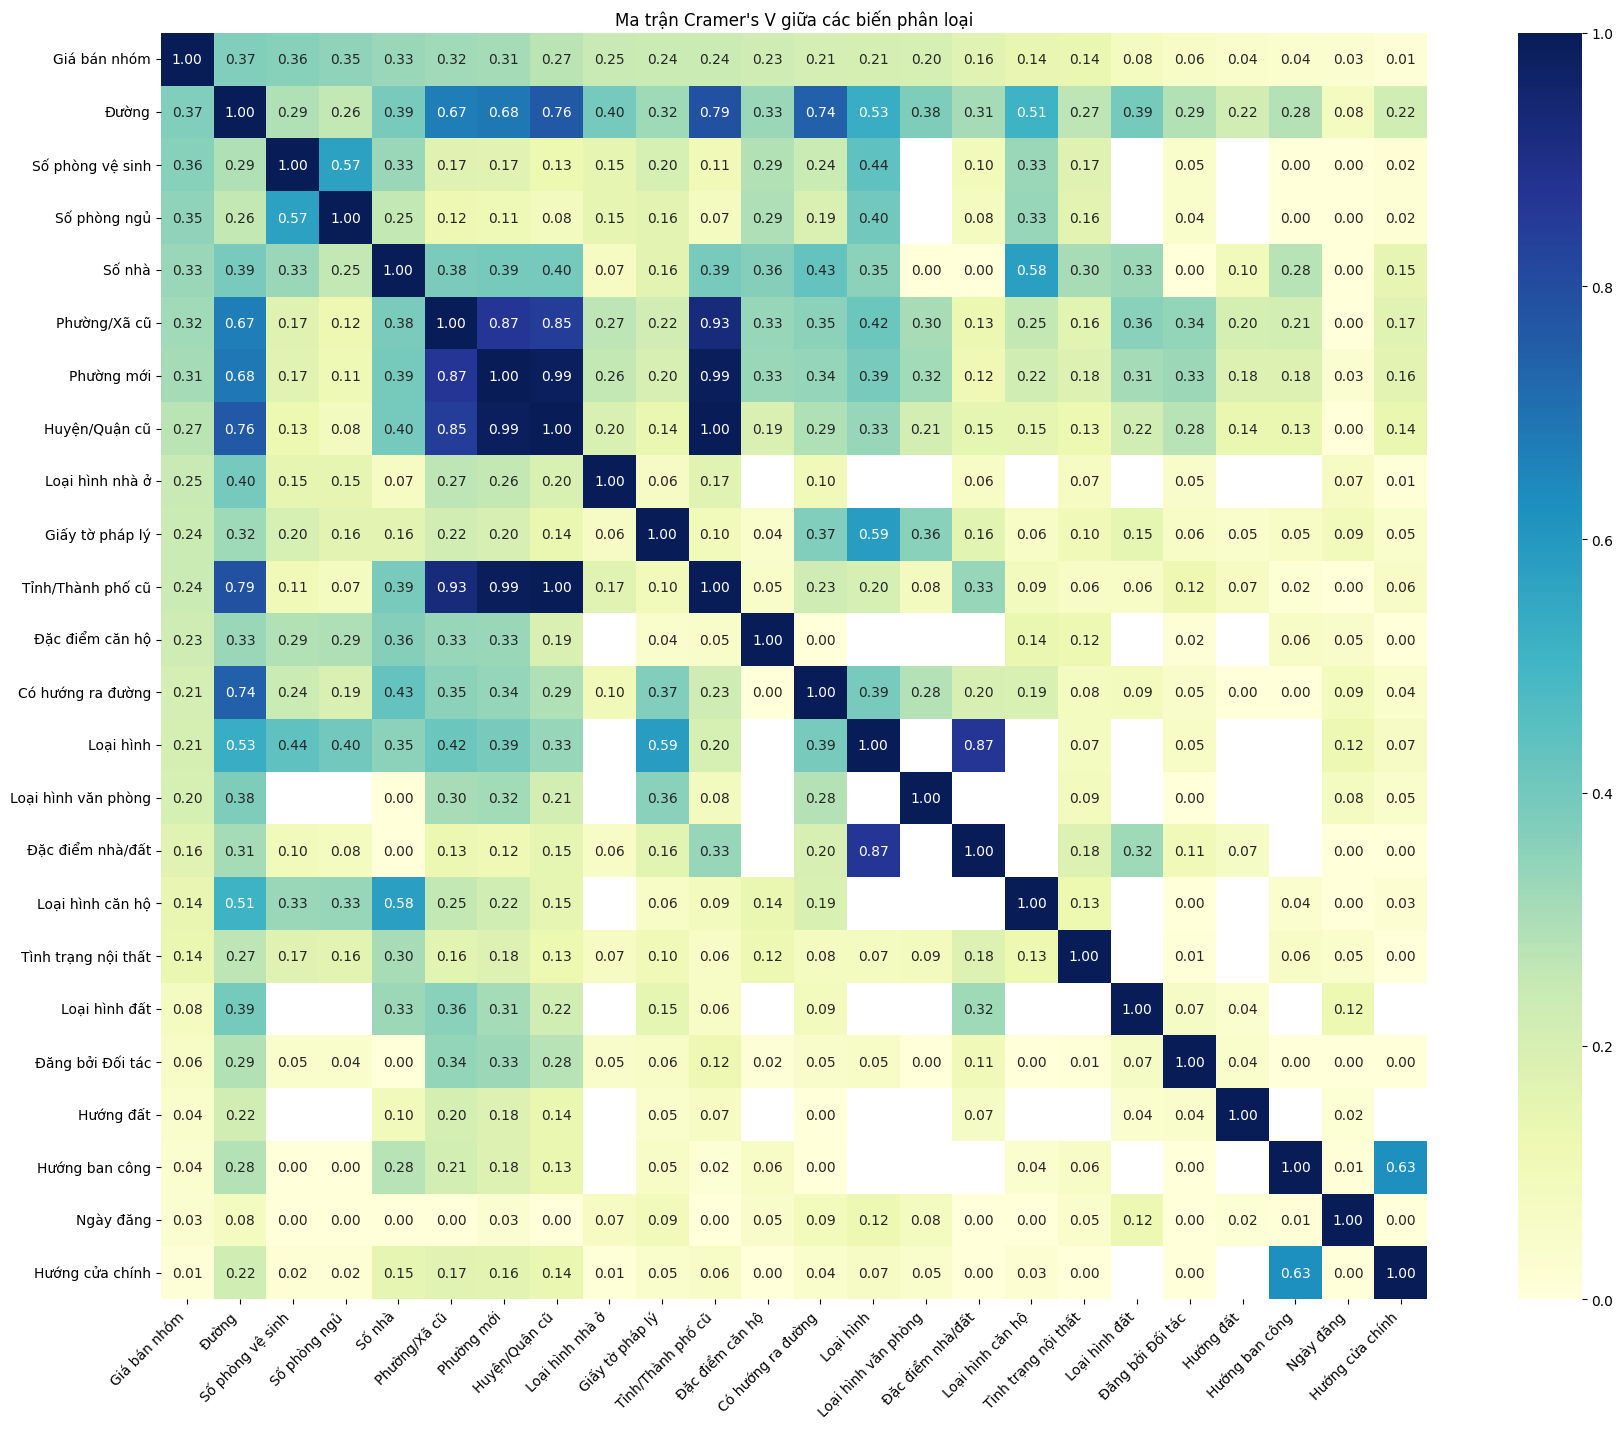

In [70]:
# Vẽ ma trận tương quan Cramer's V giữa các biến phân loại
target_col = 'Giá bán'
columns_lists = data.select_dtypes(include=['object', 'bool']).columns.tolist()
for extra_col in ['Ngày đăng', 'Ngay đăng']:
    if extra_col in data.columns and extra_col not in columns_lists:
        columns_lists.append(extra_col)

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        return np.nan

    n = contingency_table.to_numpy().sum()
    if n <= 1:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    r, k = contingency_table.shape
    phi2 = chi2 / n

    # Bias-corrected Cramer's V để kết quả ổn định hơn.
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)

analysis_df = data[columns_lists + [target_col]].copy()
analysis_df['Giá bán nhóm'] = pd.qcut(analysis_df[target_col], q=5, duplicates='drop')

categorical_cols = columns_lists + ['Giá bán nhóm']
cramers_v_matrix = pd.DataFrame(
    np.eye(len(categorical_cols)),
    index=categorical_cols,
    columns=categorical_cols
)

for i, col_1 in enumerate(categorical_cols):
    for j in range(i + 1, len(categorical_cols)):
        col_2 = categorical_cols[j]
        temp = analysis_df[[col_1, col_2]].dropna()
        if temp.empty:
            score = np.nan
        else:
            score = cramers_v(temp[col_1].astype(str), temp[col_2].astype(str))

        cramers_v_matrix.loc[col_1, col_2] = score
        cramers_v_matrix.loc[col_2, col_1] = score

sort_order = cramers_v_matrix['Giá bán nhóm'].sort_values(
    ascending=False,
    na_position='last'
).index
cramers_v_matrix = cramers_v_matrix.loc[sort_order, sort_order]

display(cramers_v_matrix.round(3))

plt.figure(figsize=(max(10, len(categorical_cols) * 0.8), max(8, len(categorical_cols) * 0.6)))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    square=True
)
plt.title("Ma trận Cramer's V giữa các biến phân loại")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [71]:
# # Đo độ tương quan giữa một số tổ hợp biến và Giá bán
# target_col = 'Giá bán'
# target_bins = 5
# numeric_bins = 5
# high_cardinality_top_n = 30
# strong_pair_threshold = 0.60

# # Bạn có thể thêm tổ hợp mới ở đây nếu muốn.
# feature_combo_candidates = {
#     'vi_tri_co_ban': ['Kinh độ', 'Vĩ độ'],
#     'vi_tri_va_dien_tich': ['Kinh độ', 'Vĩ độ', 'Diện tích'],
#     'vi_tri_va_loai_hinh': ['Kinh độ', 'Vĩ độ', 'Loại hình'],
#     'vi_tri_va_loai_hinh_nha_o': ['Kinh độ', 'Vĩ độ', 'Loại hình nhà ở'],
#     'vi_tri_va_loai_hinh_can_ho': ['Kinh độ', 'Vĩ độ', 'Loại hình căn hộ'],
#     'loai_hinh_chung_va_dien_tich': ['Loại hình', 'Diện tích'],
#     'loai_hinh_nha_o_va_dien_tich': ['Loại hình nhà ở', 'Diện tích'],
#     'loai_hinh_can_ho_va_dien_tich': ['Loại hình căn hộ', 'Diện tích'],
#     'loai_hinh_va_so_phong': ['Loại hình', 'Số phòng ngủ', 'Số phòng vệ sinh'],
#     'loai_hinh_nha_o_va_so_phong': ['Loại hình nhà ở', 'Số phòng ngủ', 'Số phòng vệ sinh'],
#     'loai_hinh_can_ho_va_so_phong': ['Loại hình căn hộ', 'Số phòng ngủ', 'Số phòng vệ sinh'],
#     'loai_dat_va_dien_tich': ['Loại đất', 'Diện tích'],
#     'dia_chi_cu_day_du': ['Tỉnh/Thành phố cũ', 'Huyện/Quận cũ', 'Phường/Xã cũ'],
#     'duong_va_vi_tri': ['Đường', 'Kinh độ', 'Vĩ độ'],
#     'to_hop_1': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh'],
#     'to_hop_2': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Số tầng', 'Giấy tờ pháp lý'],
#     'to_hop_3': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_4': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_5': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_6': [ 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_7': [ 'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Tỉnh/Thành phố cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_8': ['Phường mới', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
#     'to_hop_9': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Hướng ban công', 'Hướng đất'],
#     'to_hop_10': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Giấy tờ pháp lý'],
#     'to_hop_11': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất'],
#     'to_hop_12': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất'],
#     'to_hop_13': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
#     'to_hop_14': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
#     'to_hop_15': ['Kinh độ', 'Vĩ độ', 'Đường', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
# }

# def cramers_v(x, y):
#     contingency_table = pd.crosstab(x, y)
#     if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
#         return np.nan

#     n = contingency_table.to_numpy().sum()
#     if n <= 1:
#         return np.nan

#     chi2 = chi2_contingency(contingency_table)[0]
#     r, k = contingency_table.shape
#     phi2 = chi2 / n
#     phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
#     rcorr = r - ((r - 1) ** 2) / (n - 1)
#     kcorr = k - ((k - 1) ** 2) / (n - 1)
#     denominator = min(kcorr - 1, rcorr - 1)

#     if denominator <= 0:
#         return np.nan

#     return np.sqrt(phi2corr / denominator)

# def safe_qcut(series, q=5):
#     series = pd.to_numeric(series, errors='coerce')
#     valid = series.dropna()
#     nunique = valid.nunique()
#     if nunique < 2:
#         return pd.Series(np.nan, index=series.index, dtype='object')

#     bins = min(q, nunique)
#     try:
#         return pd.qcut(series, q=bins, duplicates='drop')
#     except ValueError:
#         ranked = series.rank(method='first')
#         return pd.qcut(ranked, q=bins, duplicates='drop')

# def to_effective_numeric(series, min_ratio=0.8):
#     numeric_series = pd.to_numeric(series, errors='coerce')
#     non_null_count = series.notna().sum()
#     if non_null_count == 0:
#         return None

#     if numeric_series.notna().sum() / non_null_count >= min_ratio:
#         return numeric_series

#     return None

# def prepare_series_for_combo(series, num_bins=5, top_n=30):
#     numeric_series = to_effective_numeric(series)
#     if numeric_series is not None:
#         prepared = safe_qcut(numeric_series, q=num_bins)
#         return prepared.astype(str).replace('nan', 'Missing')

#     prepared = series.astype('string').fillna('Missing').str.strip()
#     if prepared.nunique(dropna=True) > top_n:
#         top_values = prepared.value_counts().head(top_n).index
#         prepared = prepared.where(prepared.isin(top_values), 'Khác')

#     return prepared.astype(str)

# def build_combo_feature(df, columns, num_bins=5, top_n=30):
#     prepared_parts = []
#     for col in columns:
#         prepared_series = prepare_series_for_combo(df[col], num_bins=num_bins, top_n=top_n)
#         prepared_parts.append(prepared_series.rename(col))

#     combo_df = pd.concat(prepared_parts, axis=1).fillna('Missing').astype(str)
#     combo_feature = combo_df.iloc[:, 0]
#     for col in combo_df.columns[1:]:
#         combo_feature = combo_feature.str.cat(combo_df[col], sep=' | ')

#     return combo_feature

# def score_combo_with_target(df, columns, target_col='Giá bán', target_bins=5, num_bins=5, top_n=30):
#     available_cols = [col for col in columns if col in df.columns]
#     missing_cols = [col for col in columns if col not in df.columns]
#     if not available_cols:
#         return np.nan, missing_cols, 0

#     temp = df[available_cols + [target_col]].copy()
#     temp[target_col] = pd.to_numeric(temp[target_col], errors='coerce')
#     temp['Giá bán nhóm'] = safe_qcut(temp[target_col], q=target_bins)
#     temp = temp.dropna(subset=['Giá bán nhóm'])
#     if temp.empty:
#         return np.nan, missing_cols, 0

#     combo_feature = build_combo_feature(temp, available_cols, num_bins=num_bins, top_n=top_n)
#     score = cramers_v(combo_feature.astype(str), temp['Giá bán nhóm'].astype(str))
#     return score, missing_cols, combo_feature.nunique(dropna=True)

# all_features_in_combos = sorted({
#     col
#     for combo_cols in feature_combo_candidates.values()
#     for col in combo_cols
#     if col in data.columns
# })

# single_feature_scores = {}
# for col in all_features_in_combos:
#     single_score, _, _ = score_combo_with_target(
#         data,
#         [col],
#         target_col=target_col,
#         target_bins=target_bins,
#         num_bins=numeric_bins,
#         top_n=high_cardinality_top_n,
#     )
#     single_feature_scores[col] = single_score

# combo_results = []
# for combo_name, combo_cols in feature_combo_candidates.items():
#     available_cols = [col for col in combo_cols if col in data.columns]
#     score, missing_cols, unique_states = score_combo_with_target(
#         data,
#         combo_cols,
#         target_col=target_col,
#         target_bins=target_bins,
#         num_bins=numeric_bins,
#         top_n=high_cardinality_top_n,
#     )

#     best_single_score = max(
#         (single_feature_scores.get(col, np.nan) for col in available_cols),
#         default=np.nan,
#     )

#     combo_results.append({
#         'Tổ hợp': combo_name,
#         'Các biến': ', '.join(combo_cols),
#         'Số biến': len(combo_cols),
#         'Số trạng thái sau gom': unique_states,
#         "Cramer's V với Giá bán": score,
#         'Biến đơn tốt nhất trong tổ hợp': best_single_score,
#         'Mức tăng so với biến đơn tốt nhất': score - best_single_score if pd.notna(score) and pd.notna(best_single_score) else np.nan,
#         'Cột thiếu': ', '.join(missing_cols) if missing_cols else '',
#     })

# combo_scores_df = pd.DataFrame(combo_results).sort_values(
#     by="Cramer's V với Giá bán",
#     ascending=False,
#     na_position='last'
# ).reset_index(drop=True)

# display(combo_scores_df.round(3))

# plt.figure(figsize=(10, max(4, len(combo_scores_df) * 0.45)))
# sns.barplot(
#     data=combo_scores_df,
#     y='Tổ hợp',
#     x="Cramer's V với Giá bán",
#     hue='Tổ hợp',
#     dodge=False,
#     palette='crest',
#     legend=False
# )
# plt.title("Điểm tương quan của các tổ hợp biến với Giá bán")
# plt.xlim(0, 1)
# plt.tight_layout()

# strong_pair_list = []
# if 'cramers_v_matrix' in globals():
#     matrix_cols = [col for col in cramers_v_matrix.columns if col != 'Giá bán nhóm']
#     for i, col_1 in enumerate(matrix_cols):
#         for j in range(i + 1, len(matrix_cols)):
#             col_2 = matrix_cols[j]
#             score = cramers_v_matrix.loc[col_1, col_2]
#             if pd.notna(score) and score >= strong_pair_threshold:
#                 strong_pair_list.append([col_1, col_2])

# strong_pair_df = pd.DataFrame(strong_pair_list, columns=['Biến 1', 'Biến 2']) if strong_pair_list else pd.DataFrame(columns=['Biến 1', 'Biến 2'])
# if not strong_pair_df.empty:
#     strong_pair_df["Cramer's V giữa 2 biến"] = [cramers_v_matrix.loc[row['Biến 1'], row['Biến 2']] for _, row in strong_pair_df.iterrows()]
#     strong_pair_df = strong_pair_df.sort_values(
#         by="Cramer's V giữa 2 biến",
#         ascending=False
#     ).reset_index(drop=True)

# display(strong_pair_df.round(3))

# strong_pair_combo_candidates = {
#     f'strong_pair_{idx + 1}__{pair[0]}__{pair[1]}': pair
#     for idx, pair in enumerate(strong_pair_list)
# }

# print('feature_combo_candidates =')
# display(feature_combo_candidates)
# print('strong_pair_list =')
# display(strong_pair_list)
# print('strong_pair_combo_candidates =')
# display(strong_pair_combo_candidates)


,Metric,Why this metric is useful
0,RMSLE,Important when price spans many orders of magn...
1,MAPE (%),Average relative error; easier to read than ra...
2,SMAPE (%),More stable than MAPE when comparing cheap vs ...
3,MedianAE (bn VND),Robust absolute error; less sensitive to outli...
4,Within 10% (%),Share of predictions within +/-10% of actual p...
5,Within 20% (%),Share of predictions within +/-20% of actual p...
6,Accuracy / F1 Macro,"Only for Logistic / Softmax on price bins, not..."


Model benchmark results


,Combo,Model,Task,Num Features,Train Rows,Test Rows,MAE (bn VND),MedianAE (bn VND),RMSE (bn VND),RMSLE,MAPE (%),SMAPE (%),Within 10% (%),Within 20% (%),R2,Accuracy,Balanced Accuracy,F1 Macro,Status
0,Combo_2,XGBoost Regressor,regression,10,30825,7707,5.4313,0.8402,170.3551,0.4534,65.2474,25.4296,29.7781,55.3004,0.0044,NaN,NaN,NaN,OK
1,Combo_4,XGBoost Regressor,regression,12,30825,7707,5.4206,0.8362,170.3723,0.4538,85.2100,25.4220,29.9728,55.0019,0.0042,NaN,NaN,NaN,OK
2,Combo_3,XGBoost Regressor,regression,9,30825,7707,5.7051,0.9132,170.3994,0.4786,73.4346,27.8043,27.7021,50.8369,0.0039,NaN,NaN,NaN,OK
3,Combo_1,XGBoost Regressor,regression,8,30825,7707,5.7042,0.9429,170.3717,0.4931,68.3466,28.4891,26.1061,49.9027,0.0042,NaN,NaN,NaN,OK
4,Combo_3,Ridge Regression,regression,9,30825,7707,6.7164,1.3584,170.5695,0.6515,68.3355,39.4465,18.9568,36.3566,0.0019,NaN,NaN,NaN,OK
5,Combo_3,Lasso Regression,regression,9,30825,7707,6.7300,1.3465,170.5923,0.6572,74.0422,39.4669,19.2682,37.1351,0.0017,NaN,NaN,NaN,OK
6,Combo_4,Ridge Regression,regression,12,30825,7707,6.7532,1.3997,170.5581,0.6665,80.1242,40.5775,18.0745,35.5261,0.0021,NaN,NaN,NaN,OK
7,Combo_4,Lasso Regression,regression,12,30825,7707,6.7630,1.3991,170.5858,0.6703,79.5458,40.7504,18.3080,35.7597,0.0017,NaN,NaN,NaN,OK
8,Combo_1,Ridge Regression,regression,8,30825,7707,6.7714,1.4162,170.5696,0.6717,80.5733,40.9168,17.9577,35.2147,0.0019,NaN,NaN,NaN,OK
9,Combo_2,Ridge Regression,regression,10,30825,7707,6.7729,1.4144,170.5684,0.6720,80.4867,40.9309,17.8279,35.1109,0.0019,NaN,NaN,NaN,OK


Best model for each combo


,Combo,Model,Task,Num Features,Train Rows,Test Rows,MAE (bn VND),MedianAE (bn VND),RMSE (bn VND),RMSLE,MAPE (%),SMAPE (%),Within 10% (%),Within 20% (%),R2,Accuracy,Balanced Accuracy,F1 Macro,Status
0,Combo_1,XGBoost Regressor,regression,8,30825,7707,5.7042,0.9429,170.3717,0.4931,68.3466,28.4891,26.1061,49.9027,0.0042,0.4957,0.4957,0.4918,OK
1,Combo_2,XGBoost Regressor,regression,10,30825,7707,5.4313,0.8402,170.3551,0.4534,65.2474,25.4296,29.7781,55.3004,0.0044,0.4950,0.4950,0.4909,OK
2,Combo_3,XGBoost Regressor,regression,9,30825,7707,5.7051,0.9132,170.3994,0.4786,73.4346,27.8043,27.7021,50.8369,0.0039,0.5090,0.5089,0.5049,OK
3,Combo_4,XGBoost Regressor,regression,12,30825,7707,5.4206,0.8362,170.3723,0.4538,85.2100,25.4220,29.9728,55.0019,0.0042,0.5067,0.5066,0.5034,OK


Best overall: Combo_2 | XGBoost Regressor


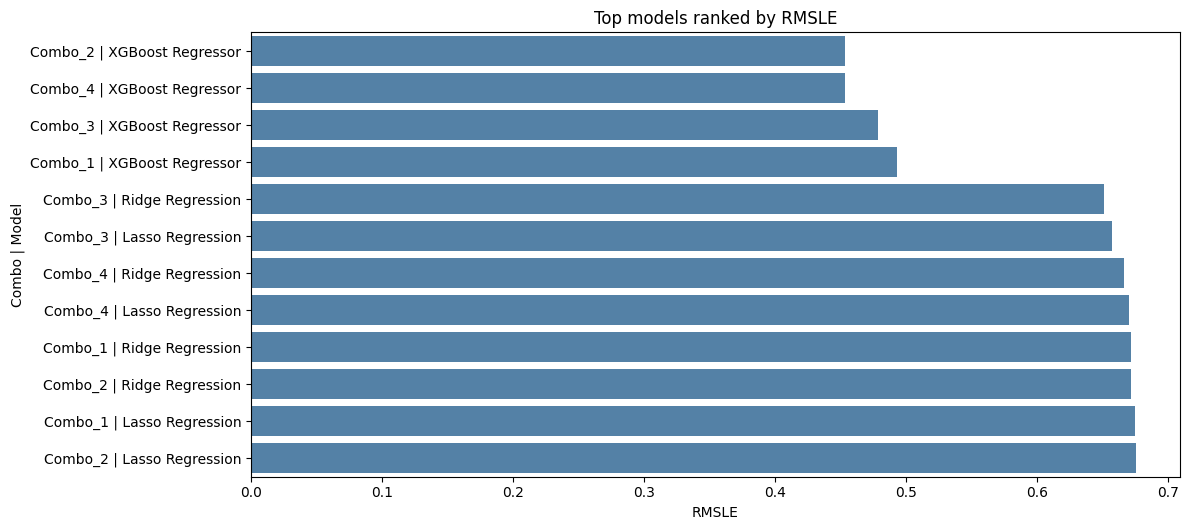

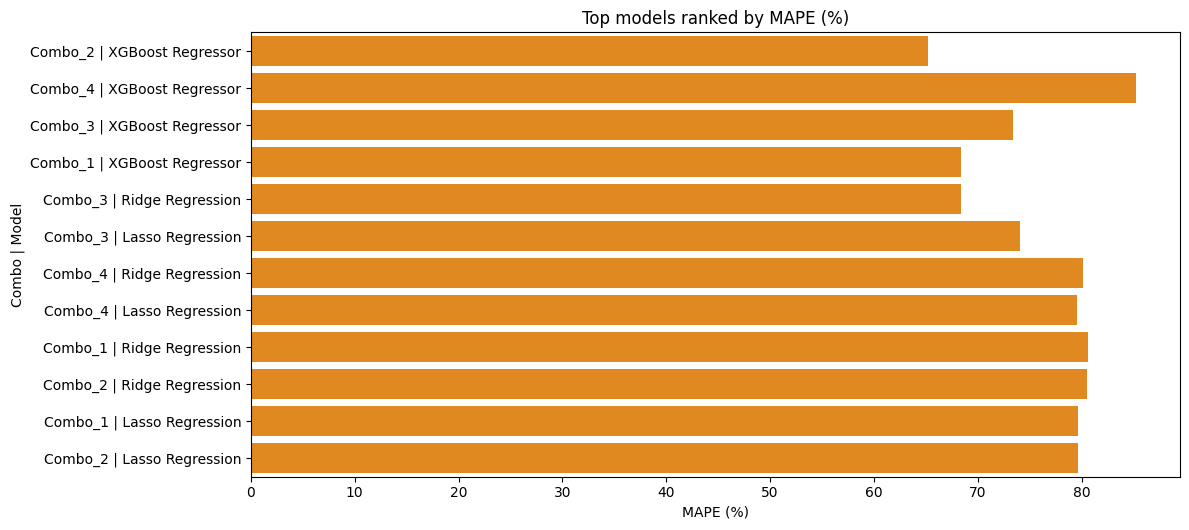

In [72]:
feature_combo_dict = {
    'Combo_1': [
        'Huyện/Quận cũ', 'Loại hình', 'Diện tích',
        'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở',
        'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ],
    'Combo_2': [
        'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích',
        'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở',
        'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ],
    'Combo_3': [
        'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ',
        'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ',
        'Loại hình đất', 'Loại hình văn phòng', 'Giấy tờ pháp lý'
    ],
    'Combo_4': [
        'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Tỉnh/Thành phố cũ', 'Loại hình',
        'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường',
        'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'
    ]
}

import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

TARGET_COL = 'Gi\u00e1 b\u00e1n'
RANDOM_STATE = 42
TEST_SIZE = 0.20
PRICE_CLASS_BINS = 5
RARE_TOP_N = 30
RARE_MIN_FREQUENCY = 20
MIN_NON_NULL_RATIO = 0.05


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    valid_mask = denominator > 0
    if not valid_mask.any():
        return np.nan
    return np.mean(np.abs(y_pred[valid_mask] - y_true[valid_mask]) / denominator[valid_mask]) * 100


def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true, dtype=float), a_min=0, a_max=None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


def within_pct(y_true, y_pred, threshold=0.10):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    relative_error = np.abs(y_pred - y_true) / np.clip(np.abs(y_true), a_min=1.0, a_max=None)
    return (relative_error <= threshold).mean() * 100


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), a_min=0, a_max=None)

    mae_value = mean_absolute_error(y_true, y_pred)
    medae_value = median_absolute_error(y_true, y_pred)
    rmse_value = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        'MAE (bn VND)': mae_value / 1e9,
        'MedianAE (bn VND)': medae_value / 1e9,
        'RMSE (bn VND)': rmse_value / 1e9,
        'RMSLE': rmsle(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'SMAPE (%)': smape(y_true, y_pred),
        'Within 10% (%)': within_pct(y_true, y_pred, threshold=0.10),
        'Within 20% (%)': within_pct(y_true, y_pred, threshold=0.20),
        'R2': r2_score(y_true, y_pred),
    }


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, top_n=30, min_frequency=20, other_label='Khac', fill_value='Missing'):
        self.top_n = top_n
        self.min_frequency = min_frequency
        self.other_label = other_label
        self.fill_value = fill_value

    def _to_frame(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X)

    def fit(self, X, y=None):
        X_df = self._to_frame(X)
        self.keep_values_ = {}

        for col in X_df.columns:
            values = X_df[col].astype('string').fillna(self.fill_value)
            value_counts = values.value_counts(dropna=False)
            keep_values = value_counts.index.tolist()

            if self.min_frequency is not None:
                keep_values = [value for value in keep_values if value_counts[value] >= self.min_frequency]

            if self.top_n is not None:
                keep_values = keep_values[:self.top_n]

            if not keep_values and not value_counts.empty:
                keep_values = value_counts.index[: min(self.top_n or len(value_counts), len(value_counts))].tolist()

            self.keep_values_[col] = set(keep_values)

        return self

    def transform(self, X):
        X_df = self._to_frame(X)

        for col in X_df.columns:
            values = X_df[col].astype('string').fillna(self.fill_value)
            keep_values = self.keep_values_.get(col, set())
            X_df[col] = values.where(values.isin(keep_values), self.other_label)

        return X_df


def make_stratify_bins(y, q=5):
    y = pd.Series(y).dropna()
    if y.nunique() < 2:
        return None

    try:
        return pd.qcut(y.rank(method='first'), q=min(q, y.nunique()), labels=False, duplicates='drop')
    except ValueError:
        return None


def make_price_classes(y_train, y_test, n_bins=5):
    y_train = pd.Series(y_train).astype(float)
    y_test = pd.Series(y_test).astype(float)
    valid_train = y_train.dropna()

    if valid_train.nunique() < 2:
        return None, None, None, None

    quantile_grid = np.linspace(0, 1, min(n_bins, valid_train.nunique()) + 1)
    edges = valid_train.quantile(quantile_grid).to_numpy()
    edges = np.unique(edges)

    if len(edges) < 3:
        return None, None, None, None

    edges[0] = -np.inf
    edges[-1] = np.inf

    y_train_cls = pd.Series(pd.cut(y_train, bins=edges, labels=False, include_lowest=True), index=y_train.index)
    y_test_cls = pd.Series(pd.cut(y_test, bins=edges, labels=False, include_lowest=True), index=y_test.index)

    if y_train_cls.nunique(dropna=True) < 2:
        return None, None, None, None

    y_train_cls = y_train_cls.astype('Int64')
    y_test_cls = y_test_cls.astype('Int64')
    class_medians = y_train.groupby(y_train_cls).median().to_dict()

    return y_train_cls, y_test_cls, class_medians, edges


def build_preprocessor(X_train, numeric_cols, categorical_cols):
    transformers = []

    if numeric_cols:
        numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
        transformers.append(('num', numeric_pipeline, numeric_cols))

    if categorical_cols:
        categorical_pipeline = Pipeline([
            ('rare', RareCategoryGrouper(top_n=RARE_TOP_N, min_frequency=RARE_MIN_FREQUENCY)),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ])
        transformers.append(('cat', categorical_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder='drop')


def build_model_registry(preprocessor):
    model_registry = [
        {
            'model_name': 'Logistic Regression (OvR)',
            'task_type': 'classification',
            'estimator': Pipeline([
                ('preprocess', clone(preprocessor)),
                ('model', OneVsRestClassifier(LogisticRegression(max_iter=4000, solver='lbfgs'))),
            ]),
        },
        {
            'model_name': 'Softmax Regression',
            'task_type': 'classification',
            'estimator': Pipeline([
                ('preprocess', clone(preprocessor)),
                ('model', LogisticRegression(max_iter=4000, solver='lbfgs', multi_class='multinomial')),
            ]),
        },
        {
            'model_name': 'Ridge Regression',
            'task_type': 'regression',
            'estimator': Pipeline([
                ('preprocess', clone(preprocessor)),
                ('model', TransformedTargetRegressor(
                    regressor=Ridge(alpha=3.0),
                    func=np.log1p,
                    inverse_func=np.expm1,
                )),
            ]),
        },
        {
            'model_name': 'Lasso Regression',
            'task_type': 'regression',
            'estimator': Pipeline([
                ('preprocess', clone(preprocessor)),
                ('model', TransformedTargetRegressor(
                    regressor=Lasso(alpha=0.001, max_iter=20000),
                    func=np.log1p,
                    inverse_func=np.expm1,
                )),
            ]),
        },
    ]

    try:
        from xgboost import XGBRegressor

        model_registry.append({
            'model_name': 'XGBoost Regressor',
            'task_type': 'regression',
            'estimator': Pipeline([
                ('preprocess', clone(preprocessor)),
                ('model', TransformedTargetRegressor(
                    regressor=XGBRegressor(
                        objective='reg:squarederror',
                        n_estimators=300,
                        learning_rate=0.05,
                        max_depth=6,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_alpha=0.0,
                        reg_lambda=1.0,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                    func=np.log1p,
                    inverse_func=np.expm1,
                )),
            ]),
        })
    except ImportError:
        model_registry.append({
            'model_name': 'XGBoost Regressor',
            'task_type': 'regression',
            'estimator': None,
            'skip_reason': 'xgboost is not installed in this environment',
        })

    return model_registry


metric_guide_df = pd.DataFrame([
    ['RMSLE', 'Important when price spans many orders of magnitude; compares error on log scale.'],
    ['MAPE (%)', 'Average relative error; easier to read than raw VND error.'],
    ['SMAPE (%)', 'More stable than MAPE when comparing cheap vs expensive listings.'],
    ['MedianAE (bn VND)', 'Robust absolute error; less sensitive to outliers.'],
    ['Within 10% (%)', 'Share of predictions within +/-10% of actual price.'],
    ['Within 20% (%)', 'Share of predictions within +/-20% of actual price.'],
    ['Accuracy / F1 Macro', 'Only for Logistic / Softmax on price bins, not raw-price regression.'],
], columns=['Metric', 'Why this metric is useful'])

display(metric_guide_df)

benchmark_rows = []
trained_model_store = {}

for combo_name, requested_features in feature_combo_dict.items():
    available_features = [feature for feature in requested_features if feature in data.columns]
    missing_features = [feature for feature in requested_features if feature not in data.columns]

    if not available_features:
        benchmark_rows.append({
            'Combo': combo_name,
            'Model': 'All',
            'Task': 'N/A',
            'Status': 'SKIPPED: no requested features were found in data',
            'Missing Requested Features': ', '.join(missing_features),
        })
        continue

    model_df = data[available_features + [TARGET_COL]].copy()
    model_df[TARGET_COL] = pd.to_numeric(model_df[TARGET_COL], errors='coerce')
    model_df = model_df.dropna(subset=[TARGET_COL])
    model_df = model_df[model_df[TARGET_COL] > 0].copy()

    usable_features = []
    for feature in available_features:
        non_null_ratio = model_df[feature].notna().mean()
        unique_values = model_df[feature].nunique(dropna=True)
        if non_null_ratio >= MIN_NON_NULL_RATIO and unique_values >= 2:
            usable_features.append(feature)

    if not usable_features:
        benchmark_rows.append({
            'Combo': combo_name,
            'Model': 'All',
            'Task': 'N/A',
            'Status': 'SKIPPED: all selected features are empty or constant',
            'Missing Requested Features': ', '.join(missing_features),
        })
        continue

    X = model_df[usable_features]
    y = model_df[TARGET_COL].astype(float)

    stratify_bins = make_stratify_bins(y, q=PRICE_CLASS_BINS)
    split_kwargs = {
        'test_size': TEST_SIZE,
        'random_state': RANDOM_STATE,
    }
    if stratify_bins is not None and pd.Series(stratify_bins).nunique(dropna=True) > 1:
        split_kwargs['stratify'] = stratify_bins

    X_train, X_test, y_train, y_test = train_test_split(X, y, **split_kwargs)

    numeric_cols = [feature for feature in usable_features if pd.api.types.is_numeric_dtype(X_train[feature])]
    categorical_cols = [feature for feature in usable_features if feature not in numeric_cols]
    preprocessor = build_preprocessor(X_train, numeric_cols, categorical_cols)

    y_train_cls, y_test_cls, class_medians, class_edges = make_price_classes(y_train, y_test, n_bins=PRICE_CLASS_BINS)
    model_registry = build_model_registry(preprocessor)

    for model_spec in model_registry:
        model_name = model_spec['model_name']
        task_type = model_spec['task_type']
        common_info = {
            'Combo': combo_name,
            'Model': model_name,
            'Task': task_type,
            'Num Features': len(usable_features),
            'Numeric Features': ', '.join(numeric_cols),
            'Categorical Features': ', '.join(categorical_cols),
            'Train Rows': len(X_train),
            'Test Rows': len(X_test),
            'Missing Requested Features': ', '.join(missing_features),
        }

        if model_spec.get('estimator') is None:
            benchmark_rows.append({
                **common_info,
                'Status': f"SKIPPED: {model_spec.get('skip_reason', 'model unavailable')}",
            })
            continue

        try:
            estimator = model_spec['estimator']

            if task_type == 'classification':
                if y_train_cls is None or y_test_cls is None:
                    raise ValueError('price classes could not be created from the training split')

                valid_test_mask = y_test_cls.notna()
                estimator.fit(X_train, y_train_cls.astype(int))
                y_pred_cls = pd.Series(estimator.predict(X_test), index=X_test.index)
                y_pred_price = y_pred_cls.map(class_medians).fillna(y_train.median()).astype(float)

                price_metric_dict = regression_metrics(y_test, y_pred_price)
                class_metric_dict = {
                    'Accuracy': accuracy_score(y_test_cls[valid_test_mask].astype(int), y_pred_cls[valid_test_mask].astype(int)),
                    'Balanced Accuracy': balanced_accuracy_score(y_test_cls[valid_test_mask].astype(int), y_pred_cls[valid_test_mask].astype(int)),
                    'F1 Macro': f1_score(y_test_cls[valid_test_mask].astype(int), y_pred_cls[valid_test_mask].astype(int), average='macro'),
                }

                benchmark_rows.append({
                    **common_info,
                    **price_metric_dict,
                    **class_metric_dict,
                    'Status': 'OK',
                })

                trained_model_store[(combo_name, model_name)] = {
                    'estimator': estimator,
                    'features': usable_features,
                    'class_medians': class_medians,
                    'class_edges': class_edges,
                    'task_type': task_type,
                }

            else:
                estimator.fit(X_train, y_train)
                y_pred_price = np.clip(estimator.predict(X_test), a_min=0, a_max=None)
                price_metric_dict = regression_metrics(y_test, y_pred_price)

                benchmark_rows.append({
                    **common_info,
                    **price_metric_dict,
                    'Status': 'OK',
                })

                trained_model_store[(combo_name, model_name)] = {
                    'estimator': estimator,
                    'features': usable_features,
                    'task_type': task_type,
                }

        except Exception as error:
            benchmark_rows.append({
                **common_info,
                'Status': f'ERROR: {type(error).__name__}: {error}',
            })

benchmark_results_df = pd.DataFrame(benchmark_rows)
for metric_col in [
    'MAE (bn VND)', 'MedianAE (bn VND)', 'RMSE (bn VND)', 'RMSLE', 'MAPE (%)',
    'SMAPE (%)', 'Within 10% (%)', 'Within 20% (%)', 'R2', 'Accuracy', 'Balanced Accuracy', 'F1 Macro'
]:
    if metric_col not in benchmark_results_df.columns:
        benchmark_results_df[metric_col] = np.nan

ok_results_df = benchmark_results_df[benchmark_results_df['Status'] == 'OK'].copy()
problem_results_df = benchmark_results_df[benchmark_results_df['Status'] != 'OK'].copy()

sort_cols = ['RMSLE', 'MAPE (%)', 'MedianAE (bn VND)', 'MAE (bn VND)']
if not ok_results_df.empty:
    ok_results_df = ok_results_df.sort_values(by=sort_cols, ascending=True).reset_index(drop=True)

summary_cols = [
    'Combo', 'Model', 'Task', 'Num Features', 'Train Rows', 'Test Rows',
    'MAE (bn VND)', 'MedianAE (bn VND)', 'RMSE (bn VND)', 'RMSLE', 'MAPE (%)',
    'SMAPE (%)', 'Within 10% (%)', 'Within 20% (%)', 'R2',
    'Accuracy', 'Balanced Accuracy', 'F1 Macro', 'Status'
]

print('Model benchmark results')
display(ok_results_df[summary_cols].round(4) if not ok_results_df.empty else ok_results_df)

if not problem_results_df.empty:
    print('Skipped / failed models')
    display(problem_results_df[['Combo', 'Model', 'Task', 'Status', 'Missing Requested Features']])

if not ok_results_df.empty:
    best_model_by_combo_df = ok_results_df.groupby('Combo', as_index=False).first()
    print('Best model for each combo')
    display(best_model_by_combo_df[summary_cols].round(4))

    best_overall_row = ok_results_df.iloc[0]
    print(f"Best overall: {best_overall_row['Combo']} | {best_overall_row['Model']}")

    plot_df = ok_results_df.head(12).copy()
    plot_df['Combo | Model'] = plot_df['Combo'] + ' | ' + plot_df['Model']

    plt.figure(figsize=(12, max(4, len(plot_df) * 0.45)))
    sns.barplot(data=plot_df, y='Combo | Model', x='RMSLE', color='steelblue')
    plt.title('Top models ranked by RMSLE')
    plt.tight_layout()

    plt.figure(figsize=(12, max(4, len(plot_df) * 0.45)))
    sns.barplot(data=plot_df, y='Combo | Model', x='MAPE (%)', color='darkorange')
    plt.title('Top models ranked by MAPE (%)')
    plt.tight_layout()
